<a href="https://colab.research.google.com/github/NK47GG/shoes-image-similarity-autoencoder/blob/main/CasualShoes_Similarity_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Casual Shoes Image Similarity Search
**Architecture**: Pretrained CNN Feature Extractor (VGG16 · MobileNetV2 · ResNet50)  
**Dataset**: `paramaggarwal/fashion-product-images-dataset` → **filter: Casual Shoes only**

---
## Ringkasan Pipeline

| # | Tahap | Keterangan |
|---|---|---|
| 1 | Data Collection | Download & merge styles + images CSV |
| 2 | Filter Casual Shoes | `articleType == 'Casual Shoes'` |
| 3 | Pretrained Feature Extractor | VGG16 · MobileNetV2 · ResNet50 (tanpa Decoder, tanpa training) |
| 4 | Feature Extraction | Embeddings seluruh gambar Casual Shoes |
| 5 | Similarity Functions | Cosine · Euclidean · Manhattan · Pearson |
| 6 | Visualisasi Hasil | Gambar + label nama file + skor, per metric |
| 7 | DCG / NDCG / Recall Manual | Evaluasi manual |
| 8 | Evaluasi | 3 model × 4 metric → Recall@5/10, NDCG@5/10 |
| 9 | Gradio Interface | Upload gambar → top-K hasil dengan gambar & label |


## 0. Environment Setup

In [1]:
!pip install kagglehub gradio tensorflow seaborn --quiet

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import PIL.Image
import gradio as gr

import tensorflow as tf
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50     import preprocess_input as res_pre
from tensorflow.keras.preprocessing.image       import load_img, img_to_array
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64

print(f"TensorFlow : {tf.__version__}")
print(f"Gradio     : {gr.__version__}")


TensorFlow : 2.20.0
Gradio     : 5.50.0


## 1. Data Collection & Filter Casual Shoes

- Download dataset dari Kaggle
- Merge `styles.csv` + `images.csv` berdasarkan `id`
- Filter hanya `articleType == 'Casual Shoes'`
- Kolom `item_label` dibuat dari **nama file tanpa ekstensi** → dipakai sebagai label display


In [2]:
import kagglehub
dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
print("Dataset path:", dataset_path)


Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Dataset path: /kaggle/input/fashion-product-images-dataset


In [3]:
images_dir = os.path.join(dataset_path, "fashion-dataset", "images")

images_df = pd.read_csv(os.path.join(dataset_path, "fashion-dataset", "images.csv"))
styles_df = pd.read_csv(
    os.path.join(dataset_path, "fashion-dataset", "styles.csv"),
    on_bad_lines="skip"
)

images_df["id"] = images_df["filename"].str.replace(".jpg", "", regex=False).astype(int)
image_files     = set(os.listdir(images_dir))

data = styles_df.merge(images_df, on="id", how="left").reset_index(drop=True)
data["filepath"]   = data["id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))
data["file_found"] = data["id"].apply(lambda x: f"{x}.jpg" in image_files)
data = data[data["file_found"]].reset_index(drop=True)

# ── Filter: Casual Shoes saja ─────────────────────────────────────────────────
shoes = data[data["articleType"] == "Casual Shoes"].reset_index(drop=True)

# Label dari nama file (tanpa path, tanpa .jpg)
shoes["item_label"] = shoes["filepath"].apply(
    lambda p: os.path.splitext(os.path.basename(p))[0]
)

print(f"Total dataset           : {len(data):,}")
print(f"Casual Shoes            : {len(shoes):,}")
print()
print("Contoh data:")
print(shoes[["id","item_label","gender","baseColour","articleType"]].head(8).to_string(index=False))


Total dataset           : 44,419
Casual Shoes            : 2,845

Contoh data:
   id item_label gender baseColour  articleType
 9204       9204    Men      Black Casual Shoes
39988      39988    Men      White Casual Shoes
22198      22198    Men      Black Casual Shoes
29570      29570    Men     Purple Casual Shoes
26538      26538    Men        Red Casual Shoes
49495      49495    Men      Khaki Casual Shoes
19311      19311    Men      White Casual Shoes
49461      49461    Men       Blue Casual Shoes


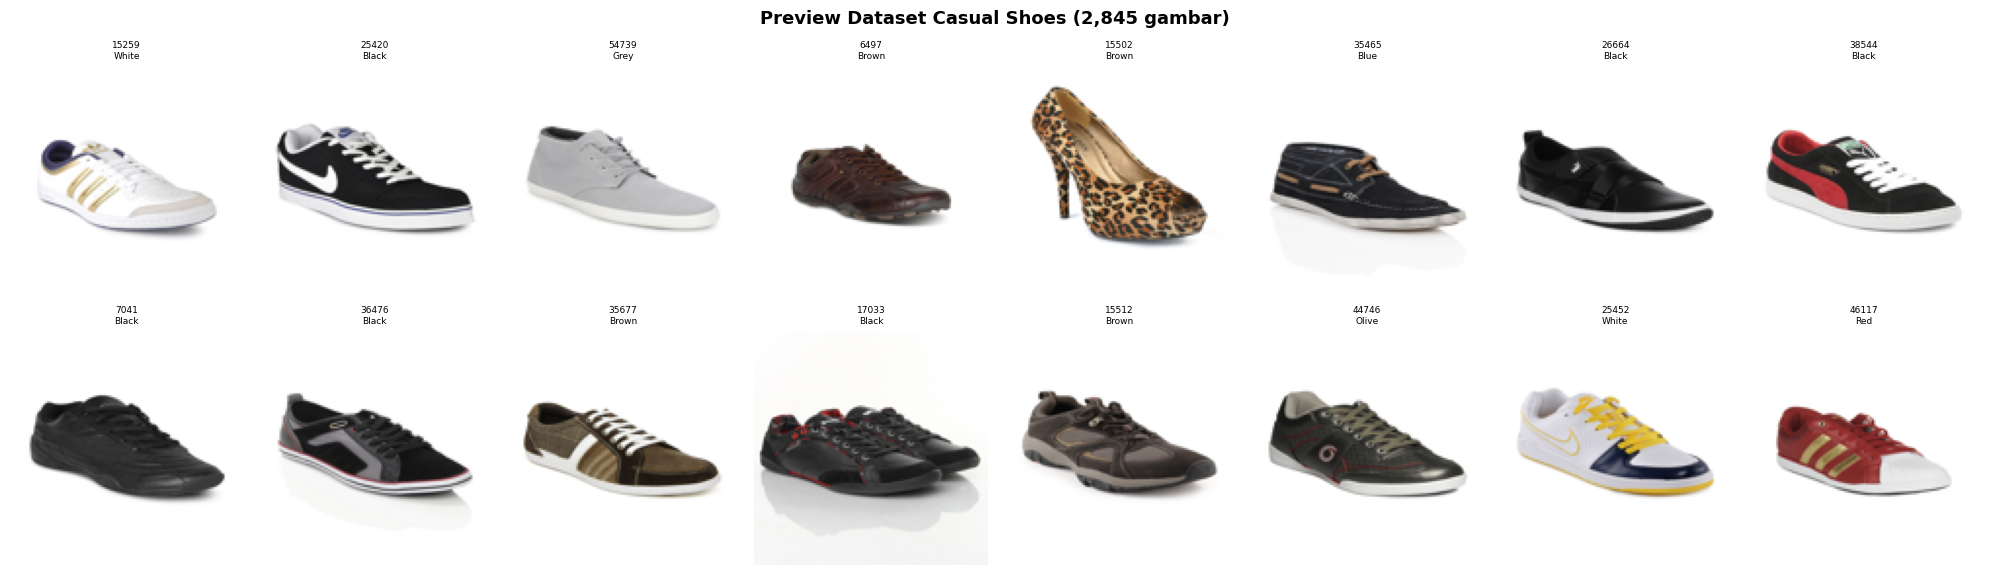

In [4]:
# ── Preview gambar Casual Shoes ───────────────────────────────────────────────
sample_preview = shoes.sample(16, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, (_, row) in zip(axes.flatten(), sample_preview.iterrows()):
    try:
        img = PIL.Image.open(row["filepath"]).resize((120, 120))
        ax.imshow(img)
    except Exception:
        ax.set_facecolor("#eee")
    ax.set_title(f"{row['item_label']}\n{row.get('baseColour','')}", fontsize=6.5)
    ax.axis("off")

plt.suptitle(f"Preview Dataset Casual Shoes ({len(shoes):,} gambar)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("casual_shoes_preview.png", dpi=130, bbox_inches="tight")
plt.show()


## 2. Pretrained Feature Extractor — Tanpa Decoder, Tanpa Training

Tiga model dari `keras.applications` — semua weight pretrained ImageNet.  
`include_top=False, pooling='avg'` → langsung menghasilkan feature vector.

| Model | Output Dim | Params |
|---|---|---|
| VGG16 | 512 | ~14.7M |
| MobileNetV2 | 1280 | ~2.2M |
| ResNet50 | 2048 | ~23.5M |


In [5]:
def build_extractor(name):
    kw = dict(weights="imagenet", include_top=False,
               pooling="avg", input_shape=(224, 224, 3))
    if name == "VGG16":
        m, fn = VGG16(**kw),       vgg_pre
    elif name == "MobileNetV2":
        m, fn = MobileNetV2(**kw),  mob_pre
    elif name == "ResNet50":
        m, fn = ResNet50(**kw),     res_pre
    else:
        raise ValueError(name)
    m.trainable = False
    return m, fn

models_dict = {}
for mname in ["VGG16", "MobileNetV2", "ResNet50"]:
    m, fn = build_extractor(mname)
    models_dict[mname] = {"model": m, "preprocess": fn}
    print(f"✓ {mname:15s} | dim={m.output_shape[-1]:>5d} | params={m.count_params():,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ VGG16           | dim=  512 | params=14,714,688
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ MobileNetV2     | dim= 1280 | params=2,257,984
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ ResNet50        | dim= 2048 | params=23,587,712


## 3. Feature Extraction — Embeddings Seluruh Casual Shoes

In [ ]:
def extract_embeddings(df, model, prep_fn, img_size=IMG_SIZE, batch=BATCH_SIZE):
    all_embs, valid_idx = [], []
    for start in range(0, len(df), batch):
        chunk = df.iloc[start:start+batch]
        arrs, idxs = [], []
        for idx, row in chunk.iterrows():
            try:
                arr = img_to_array(load_img(row["filepath"], target_size=img_size))
                arrs.append(prep_fn(arr))
                idxs.append(idx)
            except Exception:
                continue
        if arrs:
            embs = model.predict(np.array(arrs), verbose=0)
            all_embs.extend(embs)
            valid_idx.extend(idxs)
        done = min(start + batch, len(df))
        if done % 200 == 0 or done == len(df):
            print(f"  {done}/{len(df)}", end="\r")
    return np.array(all_embs), valid_idx

databases = {}
print(f"Ekstraksi dari {len(shoes):,} gambar Casual Shoes\n")
for mname, info in models_dict.items():
    print(f"[{mname}]")
    embs, vidx = extract_embeddings(shoes, info["model"], info["preprocess"])
    vdf = shoes.iloc[vidx].reset_index(drop=True)
    databases[mname] = {"embeddings": embs, "metadata": vdf}
    joblib.dump(databases[mname], f"db_{mname.lower()}.pkl")
    print(f"  ✓ embeddings shape = {embs.shape}\n")


Ekstraksi dari 2,845 gambar Casual Shoes

[VGG16]


## 4. Similarity Functions

| Metric | Cara Kerja | Skor tinggi = makin mirip |
|---|---|---|
| **Cosine Similarity** | Sudut antar vektor | ✓ |
| **Euclidean Distance** | Jarak Euclidean, dinegasi | ✓ (lebih kecil jarak = lebih mirip) |
| **Manhattan Distance** | Jarak Manhattan, dinegasi | ✓ |
| **Pearson Correlation** | Korelasi linear antar vektor | ✓ |

> Cosine = 1.0 (item identik / diri sendiri) **dikecualikan** dari hasil, tapi top-K tetap penuh.


In [ ]:
def cosine_scores(q, db):
    return sk_cosine(q.reshape(1, -1), db)[0]

def euclidean_scores(q, db):
    return -np.sqrt(((db - q) ** 2).sum(axis=1))

def manhattan_scores(q, db):
    return -np.abs(db - q).sum(axis=1)

def pearson_scores(q, db):
    q_c = q - q.mean()
    q_s = q.std()
    d_c = db - db.mean(axis=1, keepdims=True)
    d_s = db.std(axis=1)
    if q_s == 0:
        return np.full(len(db), -1.)
    with np.errstate(invalid="ignore", divide="ignore"):
        r = (d_c * q_c).mean(axis=1) / (d_s * q_s + 1e-9)
    return np.nan_to_num(r, nan=-1.)

SIM_FNS = {
    "Cosine Similarity"              : cosine_scores,
    "Euclidean Distance"             : euclidean_scores,
    "Manhattan Distance"             : manhattan_scores,
    "Pearson Correlation Coefficient": pearson_scores,
}
SIM_SHORT = {
    "Cosine Similarity"              : "Cosine",
    "Euclidean Distance"             : "Euclid",
    "Manhattan Distance"             : "Manhatt",
    "Pearson Correlation Coefficient": "Pearson",
}
print("Similarity functions ready:", list(SIM_FNS.keys()))


## 5. Retrieval Helper

In [ ]:
def prep_query(src, prep_fn, img_size=IMG_SIZE):
    """Path string atau PIL.Image → preprocessed tensor (1,H,W,3)."""
    if isinstance(src, str):
        arr = img_to_array(load_img(src, target_size=img_size))
    else:
        img = src.resize(img_size)
        arr = np.array(img)
        if arr.ndim == 2:
            arr = np.stack([arr]*3, axis=-1)
        elif arr.shape[-1] == 4:
            arr = arr[:, :, :3]
        arr = arr.astype("float32")
    return prep_fn(arr)[np.newaxis]

def retrieve(query_emb, query_id, db, sim_fn, top_k=10):
    """
    Return top-K DataFrame + seluruh skor.
    - Item dengan id sama dengan query dikecualikan (termasuk kasus cosine=1.0).
    - top_k=5 atau top_k=10 tetap dikembalikan penuh.
    """
    embs, meta = db["embeddings"], db["metadata"]
    scores     = sim_fn(query_emb, embs)
    idx        = np.argsort(scores)[::-1]

    if query_id is not None:
        idx = [i for i in idx if meta.iloc[i]["id"] != query_id]

    top    = list(idx[:top_k])
    res    = meta.iloc[top].copy().reset_index(drop=True)
    res["score"] = scores[np.array(top)]
    return res, scores


## 6. Visualisasi Similarity — Gambar + Label Nama File

Untuk satu query, semua 4 metric ditampilkan sekaligus dalam satu figure:
- **Setiap baris** = 1 similarity metric
- **Setiap kolom** = 1 hasil (top-5)
- Setiap thumbnail dilengkapi:
  - **Nama file** (item_label = ID produk dari nama file)
  - **Warna & gender**
  - **Skor similarity**
  - Border **hijau** di rank #1


In [ ]:
def visualize_similarity(query_src, model_name, top_k=5, save_path=None):
    """
    Grid visualisasi: 4 metric (baris) × top_k hasil (kolom).
    Kolom paling kiri = gambar query.
    Setiap thumbnail: gambar + item_label + skor.
    """
    info  = models_dict[model_name]
    db    = databases[model_name]

    # Embed query
    q_arr = prep_query(query_src, info["preprocess"])
    q_emb = info["model"].predict(q_arr, verbose=0)[0]

    # ID query untuk eksklusi
    if isinstance(query_src, str):
        try:
            qid = int(os.path.splitext(os.path.basename(query_src))[0])
        except ValueError:
            qid = None
    else:
        qid = None

    n_metric = len(SIM_FNS)
    fig, axes = plt.subplots(
        n_metric, top_k + 1,
        figsize=((top_k + 1) * 2.6, n_metric * 3.4)
    )

    # ── Query image (kolom 0) ──────────────────────────────────────────────────
    try:
        q_pil = PIL.Image.open(query_src) if isinstance(query_src, str) else query_src
        q_pil = q_pil.resize((180, 180))
    except Exception:
        q_pil = PIL.Image.new("RGB", (180, 180), (220, 220, 220))

    # Hanya label query di baris pertama, baris lain biarkan kosong
    if isinstance(query_src, str):
        q_label = os.path.splitext(os.path.basename(query_src))[0]
    else:
        q_label = "query"

    for row_i in range(n_metric):
        ax0 = axes[row_i][0]
        ax0.imshow(q_pil)
        if row_i == 0:
            ax0.set_title(f"QUERY\n{q_label}", fontsize=8,
                           fontweight="bold", color="navy")
        else:
            ax0.set_title("", fontsize=8)
        ax0.axis("off")

        # Metric label di sisi kiri
        sim_name = list(SIM_FNS.keys())[row_i]
        ax0.set_ylabel(
            SIM_SHORT[sim_name], fontsize=9, fontweight="bold",
            rotation=0, labelpad=52, va="center", color="#8B0000"
        )

    # ── Hasil similarity per metric ────────────────────────────────────────────
    for row_i, (sim_name, sim_fn) in enumerate(SIM_FNS.items()):
        res_df, _ = retrieve(q_emb, qid, db, sim_fn, top_k=top_k)

        for col_i, (_, rrow) in enumerate(res_df.iterrows()):
            ax = axes[row_i][col_i + 1]

            # Gambar
            try:
                img = PIL.Image.open(rrow["filepath"]).resize((180, 180))
                ax.imshow(img)
            except Exception:
                ax.set_facecolor("#ddd")
                ax.text(0.5, 0.5, "err", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)

            # Label: nama file + warna + gender + skor
            colour = rrow.get("baseColour", "")
            gender = rrow.get("gender", "")
            title  = (f"#{col_i+1}  {rrow['item_label']}\n"
                      f"{colour} · {gender}\n"
                      f"skor: {rrow['score']:.4f}")
            ax.set_title(title, fontsize=6.8, pad=3, linespacing=1.4)
            ax.axis("off")

            # Border hijau rank #1, abu rank lain
            border_color = "#2ca02c" if col_i == 0 else "#cccccc"
            border_width = 2.5      if col_i == 0 else 0.8
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(border_width)

    plt.suptitle(
        f"Top-{top_k} Casual Shoes Similarity — Model: {model_name}\n"
        f"Label = nama file (ID produk)  |  item identik dikecualikan",
        fontsize=11, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    fname = save_path or f"sim_{model_name.lower()}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()
    return fname


In [ ]:
# ── Demo: satu query → tampilkan 3 model × 4 metric ──────────────────────────
sample_row = shoes.sample(1, random_state=77).iloc[0]
query_path = sample_row["filepath"]

print(f"Query: {sample_row['item_label']} | "
      f"{sample_row.get('baseColour','')} | {sample_row.get('gender','')}")

# Tampilkan gambar query
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(PIL.Image.open(query_path).resize((200, 200)))
ax.set_title(f"Query\n{sample_row['item_label']}", fontweight="bold", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

# Visualisasi per model
result_fnames = {}
for mname in ["VGG16", "MobileNetV2", "ResNet50"]:
    print(f"\n--- {mname} ---")
    fname = visualize_similarity(query_path, mname, top_k=5,
                                  save_path=f"sim_{mname.lower()}.png")
    result_fnames[mname] = fname


## 7. DCG · NDCG · Recall — Dihitung Manual

```
DCG@k   = Σᵢ₌₁ᵏ  relᵢ / log₂(i+1)
IDCG@k  = DCG dari urutan relevansi ideal (semua relevant di depan)
NDCG@k  = DCG@k / IDCG@k

Recall@k = |relevant ∩ top-k| / |total_relevant_in_db|
```

**Ground truth relevansi**: item dianggap relevan jika `baseColour` **sama** dengan query  
(semua item sudah Casual Shoes, warna dipakai sebagai pembeda).


In [ ]:
def dcg(rel, k):
    r = np.array(rel[:k], dtype=float)
    if len(r) == 0:
        return 0.0
    return float((r / np.log2(np.arange(2, len(r) + 2))).sum())

def ndcg(rel, k):
    idcg = dcg(sorted(rel, reverse=True), k)
    return dcg(rel, k) / idcg if idcg else 0.0

def recall_at_k(rel, total_rel, k):
    return sum(rel[:k]) / total_rel if total_rel else 0.0

def relevance_labels(qrow, res_df):
    """Relevan = baseColour sama dengan query."""
    qc = qrow.get("baseColour", "")
    return [int(r == qc) for r in res_df["baseColour"].tolist()]

# Sanity check
_r = [1, 0, 1, 0, 1, 0, 0, 0, 0, 1]
print(f"DCG@5    = {dcg(_r, 5):.4f}")
print(f"NDCG@5   = {ndcg(_r, 5):.4f}")
print(f"NDCG@10  = {ndcg(_r, 10):.4f}")
print(f"Recall@5  = {recall_at_k(_r, 4, 5):.4f}")
print(f"Recall@10 = {recall_at_k(_r, 4, 10):.4f}")


## 8. Evaluasi — 3 Model × 4 Metric

In [ ]:
N_QUERIES = 100

def evaluate(mname, sname, sfn, db, n=N_QUERIES):
    model  = models_dict[mname]["model"]
    prep   = models_dict[mname]["preprocess"]
    meta   = db["metadata"]
    q_rows = meta.sample(min(n, len(meta)), random_state=42)

    acc = {f"{m}@{k}": [] for m in ["Recall","NDCG"] for k in [5, 10]}

    for _, qrow in q_rows.iterrows():
        try:
            q_emb = model.predict(prep_query(qrow["filepath"], prep), verbose=0)[0]
        except Exception:
            continue

        scores = sfn(q_emb, db["embeddings"])
        idx    = np.argsort(scores)[::-1]
        idx    = [i for i in idx if meta.iloc[i]["id"] != qrow["id"]]

        top10  = meta.iloc[idx[:10]].reset_index(drop=True)
        rel    = relevance_labels(qrow, top10)
        tot    = max((meta["baseColour"] == qrow.get("baseColour","")).sum() - 1, 1)

        for k in [5, 10]:
            acc[f"Recall@{k}"].append(recall_at_k(rel, tot, k))
            acc[f"NDCG@{k}"].append(ndcg(rel, k))

    return {m: float(np.mean(v)) if v else 0. for m, v in acc.items()}

eval_rows = []
print("Evaluasi 3 model × 4 metric × 100 queries...\n")
for mname in ["VGG16", "MobileNetV2", "ResNet50"]:
    for sname, sfn in SIM_FNS.items():
        print(f"  [{mname:12s}] × [{sname[:28]:28s}]", end=" ")
        res = evaluate(mname, sname, sfn, databases[mname])
        row = {"Model": mname, "Similarity": sname}
        row.update(res)
        eval_rows.append(row)
        print(f"R@5={res['Recall@5']:.3f}  NDCG@5={res['NDCG@5']:.3f}  ✓")

results_df = pd.DataFrame(eval_rows)
results_df["SimShort"] = results_df["Similarity"].map(SIM_SHORT)
print()
results_df


## 9. Visualisasi Evaluasi

In [ ]:
METRIC_COLS = ["Recall@5","Recall@10","NDCG@5","NDCG@10"]
M_COLORS    = {"VGG16":"#4C72B0","MobileNetV2":"#DD8452","ResNet50":"#55A868"}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
bw = 0.22
x  = np.arange(4)   # 4 metrics

for ax, metric in zip(axes.flatten(), METRIC_COLS):
    for i, mn in enumerate(["VGG16","MobileNetV2","ResNet50"]):
        sub  = results_df[results_df["Model"] == mn].sort_values("SimShort")
        bars = ax.bar(
            x + (i - 1) * bw, sub[metric], bw,
            label=mn, color=M_COLORS[mn], alpha=0.85,
            edgecolor="white", linewidth=0.5
        )
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(metric, fontweight="bold", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(["Cosine","Euclid","Manhatt","Pearson"], fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Evaluasi: Recall@K & NDCG@K — Casual Shoes Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 4))
for ax, metric in zip(axes, METRIC_COLS):
    pivot = results_df.pivot(index="Model", columns="SimShort", values=metric)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f",
                cmap="YlOrRd", vmin=0, vmax=1,
                cbar_kws={"shrink": 0.8}, linewidths=0.5)
    ax.set_title(metric, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Heatmap Evaluasi — Casual Shoes: Model × Similarity Metric",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eval_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Tabel Evaluasi ===")
print(results_df[["Model","Similarity"]+METRIC_COLS].to_string(index=False))


## 10. Gradio Interface (HuggingFace)

**3 Tab:**
1. **🔍 Search** — Upload gambar sepatu → top-K hasil lengkap dengan gambar, label nama file, warna, skor
2. **📊 Bandingkan 4 Metric** — Tampilkan top-5 dari semua metric sekaligus untuk 1 query
3. **📈 Hasil Evaluasi** — Tabel + chart perbandingan semua model


In [ ]:
def gallery_items(res_df):
    """Buat list (PIL.Image, caption) untuk gr.Gallery."""
    out = []
    for rank, (_, row) in enumerate(res_df.iterrows(), 1):
        try:
            img = PIL.Image.open(row["filepath"]).resize((224, 224))
        except Exception:
            img = PIL.Image.new("RGB", (224, 224), (200, 200, 200))
        caption = (f"#{rank}  |  {row['item_label']}\n"
                   f"{row.get('baseColour','')} · {row.get('gender','')}\n"
                   f"Skor: {row['score']:.4f}")
        out.append((img, caption))
    return out


def search_fn(pil_img, mname, sname, top_k):
    if pil_img is None:
        return [], pd.DataFrame()
    info  = models_dict[mname]
    db    = databases[mname]
    sfn   = SIM_FNS[sname]

    q_emb = info["model"].predict(
        prep_query(pil_img, info["preprocess"]), verbose=0)[0]
    res, _ = retrieve(q_emb, None, db, sfn, top_k=int(top_k))

    gallery = gallery_items(res)
    table   = res[["item_label", "baseColour", "gender", "score"]].rename(
                  columns={"score": "Skor"})
    return gallery, table


def compare_fn(pil_img, mname):
    if pil_img is None:
        return pd.DataFrame()
    info  = models_dict[mname]
    db    = databases[mname]
    q_emb = info["model"].predict(
        prep_query(pil_img, info["preprocess"]), verbose=0)[0]

    rows = []
    for sname, sfn in SIM_FNS.items():
        res, _ = retrieve(q_emb, None, db, sfn, top_k=5)
        rows.append({
            "Metric"       : sname,
            "Top-5 Labels" : "  |  ".join(res["item_label"].tolist()),
            "Top-5 Warna"  : "  |  ".join(res.get("baseColour", pd.Series([""]*5)).tolist()),
            "Avg Skor"     : f"{res['score'].mean():.4f}",
        })
    return pd.DataFrame(rows)


# ── UI ────────────────────────────────────────────────────────────────────────
with gr.Blocks(title="Casual Shoes Similarity Search", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 👟 Casual Shoes Image Similarity Search
    Pretrained CNN · 4 Similarity Metric · Recall & NDCG Evaluation
    Label setiap hasil = **nama file (ID produk)**
    """)

    # Tab 1: Search
    with gr.Tab("🔍 Search"):
        with gr.Row():
            with gr.Column(scale=1):
                img_in = gr.Image(type="pil", label="Upload Gambar Casual Shoes")
                m_sel  = gr.Dropdown(["VGG16","MobileNetV2","ResNet50"],
                                      value="MobileNetV2", label="Feature Extractor")
                s_sel  = gr.Dropdown(list(SIM_FNS.keys()),
                                      value="Cosine Similarity", label="Similarity Metric")
                k_sl   = gr.Slider(5, 10, step=5, value=5, label="Top-K")
                gr.Markdown("_\* Item identik dikecualikan dari hasil_")
                btn    = gr.Button("🔍 Cari Casual Shoes Mirip", variant="primary")
            with gr.Column(scale=2):
                gallery = gr.Gallery(
                    label="Hasil — Gambar + Label Nama File + Skor",
                    columns=5, height="auto"
                )
                tbl = gr.Dataframe(label="Tabel Detail Skor")
        btn.click(search_fn, [img_in, m_sel, s_sel, k_sl], [gallery, tbl])

    # Tab 2: Compare Metrics
    with gr.Tab("📊 Bandingkan 4 Metric"):
        with gr.Row():
            with gr.Column(scale=1):
                cmp_img = gr.Image(type="pil", label="Upload Gambar Casual Shoes")
                cmp_mdl = gr.Dropdown(["VGG16","MobileNetV2","ResNet50"],
                                       value="MobileNetV2", label="Model")
                cmp_btn = gr.Button("📊 Bandingkan Semua Metric", variant="primary")
            with gr.Column(scale=2):
                cmp_tbl = gr.Dataframe(label="Top-5 per Metric — Label & Warna")
        cmp_btn.click(compare_fn, [cmp_img, cmp_mdl], [cmp_tbl])

    # Tab 3: Evaluation
    with gr.Tab("📈 Hasil Evaluasi"):
        gr.Markdown("### Recall@K & NDCG@K — Semua Kombinasi Model × Metric")
        gr.Dataframe(value=results_df[["Model","Similarity"]+METRIC_COLS],
                     label="Tabel Evaluasi")
        with gr.Row():
            gr.Image(value="eval_comparison.png", label="Grouped Bar Chart")
            gr.Image(value="eval_heatmap.png",    label="Heatmap")
        with gr.Row():
            for mname in ["VGG16","MobileNetV2","ResNet50"]:
                fname = f"sim_{mname.lower()}.png"
                if os.path.exists(fname):
                    gr.Image(value=fname, label=f"Contoh Retrieval — {mname}")

demo.launch(share=True)


## 11. Download Artefak (Google Colab)

In [ ]:
import shutil

DUMP = "casual_shoes_artifacts"
os.makedirs(DUMP, exist_ok=True)

files_to_save = (
    [f"db_{m}.pkl" for m in ["vgg16","mobilenetv2","resnet50"]]
    + ["casual_shoes_preview.png","eval_comparison.png","eval_heatmap.png"]
    + [f"sim_{m.lower()}.png" for m in ["VGG16","MobileNetV2","ResNet50"]]
)

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(DUMP, f))
        print(f"  ✓ {f:<40} {os.path.getsize(os.path.join(DUMP,f))/1e6:.1f} MB")

try:
    from google.colab import files
    zip_path = shutil.make_archive("casual_shoes_artifacts","zip", DUMP)
    files.download(zip_path)
    print("\n✅ casual_shoes_artifacts.zip diunduh")
except ImportError:
    print("\nℹ️  Salin folder 'casual_shoes_artifacts/' secara manual.")
